# Diwali Sales Analysis

Exploratory data analysis of Diwali sales data (11,251 orders) to understand customer purchasing behavior — who buys, what they buy, and why — using Python (Pandas, Matplotlib, Seaborn).

## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

**Loading the dataset**

In [2]:
df = pd.read_csv('Diwali_Sales_Data.csv', encoding='unicode_escape')

**Checking the dataset**

In [3]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
df.shape

(11251, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


**Drop the blank / unrelated columns**

In [6]:
df.drop(['Status', 'unnamed1'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), str(8)
memory usage: 1.1 MB


**Check for null values**

In [8]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

**Drop the null values**

In [9]:
df.dropna(inplace=True)

**Change the datatype of the "Amount" column**

In [10]:
df['Amount'] = df['Amount'].astype('int')

In [11]:
df['Amount']

0        23952
1        23934
2        23924
3        23912
4        23877
         ...  
11246      370
11247      367
11248      213
11249      206
11250      188
Name: Amount, Length: 11239, dtype: int64

In [12]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

**Descriptive statistics (mean, median, std, etc.)**

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,11239.0,1.003004e+06,1716.038826,1000001.0,1001491.5,1003064.0,1004426.5,1006040.0
Age,11239.0,3.541036e+01,12.753866,12.0,27.0,33.0,43.0,92.0
Marital_Status,11239.0,4.200552e-01,0.493589,0.0,0.0,0.0,1.0,1.0
Orders,11239.0,2.489634e+00,1.114967,1.0,2.0,2.0,3.0,4.0
Amount,11239.0,9.453611e+03,5222.355168,188.0,5443.0,8109.0,12675.0,23952.0


**Descriptive statistics for specific columns**

In [14]:
df[["Age", "Orders", "Amount"]].describe()

,Age,Orders,Amount
count,11239.000000,11239.000000,11239.000000
mean,35.410357,2.489634,9453.610553
std,12.753866,1.114967,5222.355168
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis

## Gender

Distribution of buyers by gender

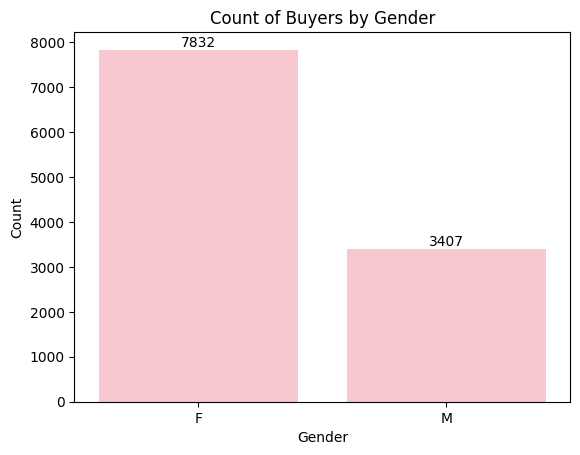

In [15]:
ax = sns.countplot(x='Gender', data=df, color='pink')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Count of Buyers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Total sales amount by gender

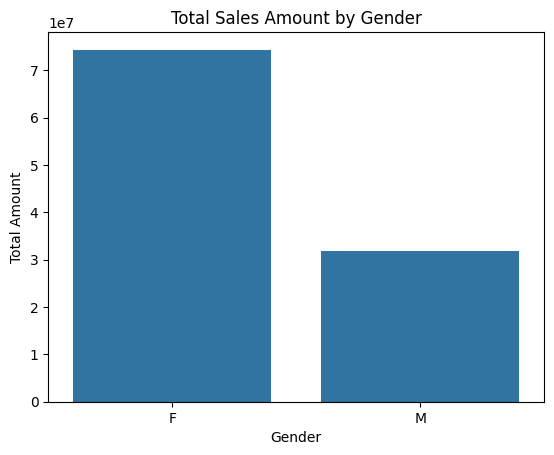

In [16]:
gender_sales = df.groupby('Gender', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Gender', y='Amount', data=gender_sales)
plt.title('Total Sales Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.show()

**From the graphs above, we can see that most buyers are female, and their purchasing power is also higher than men's.**

## Age

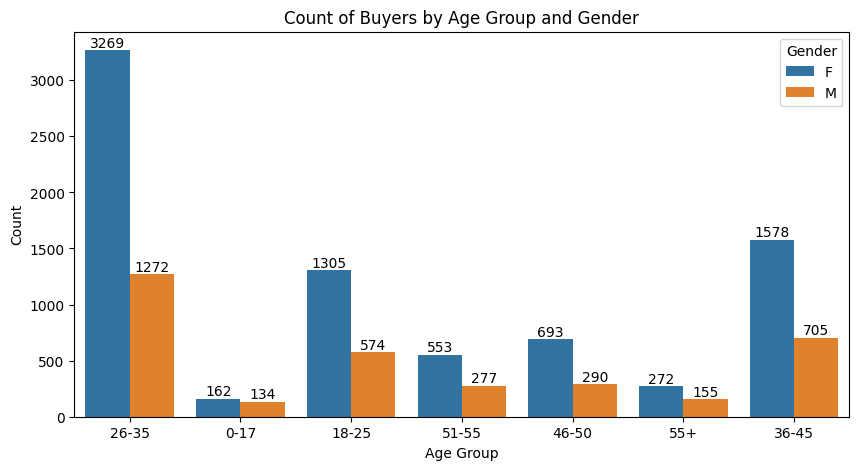

In [17]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='Age Group', hue='Gender')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Count of Buyers by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

Total sales amount by age group

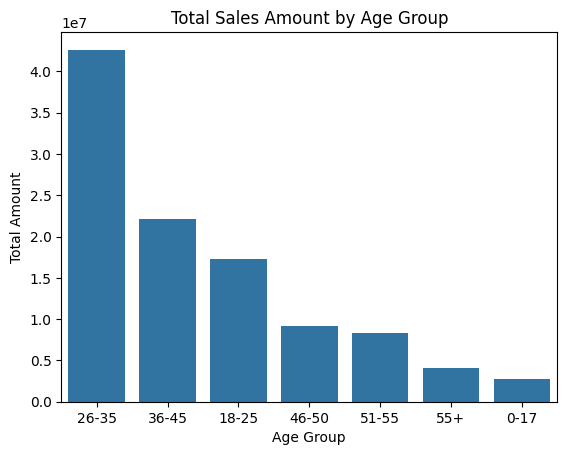

In [18]:
age_sales = df.groupby('Age Group', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x='Age Group', y='Amount', data=age_sales)
plt.title('Total Sales Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.show()

**From the graph above, we can see that most buyers are from the 26-35 age group.**

## States

Total number of orders from the top 10 states

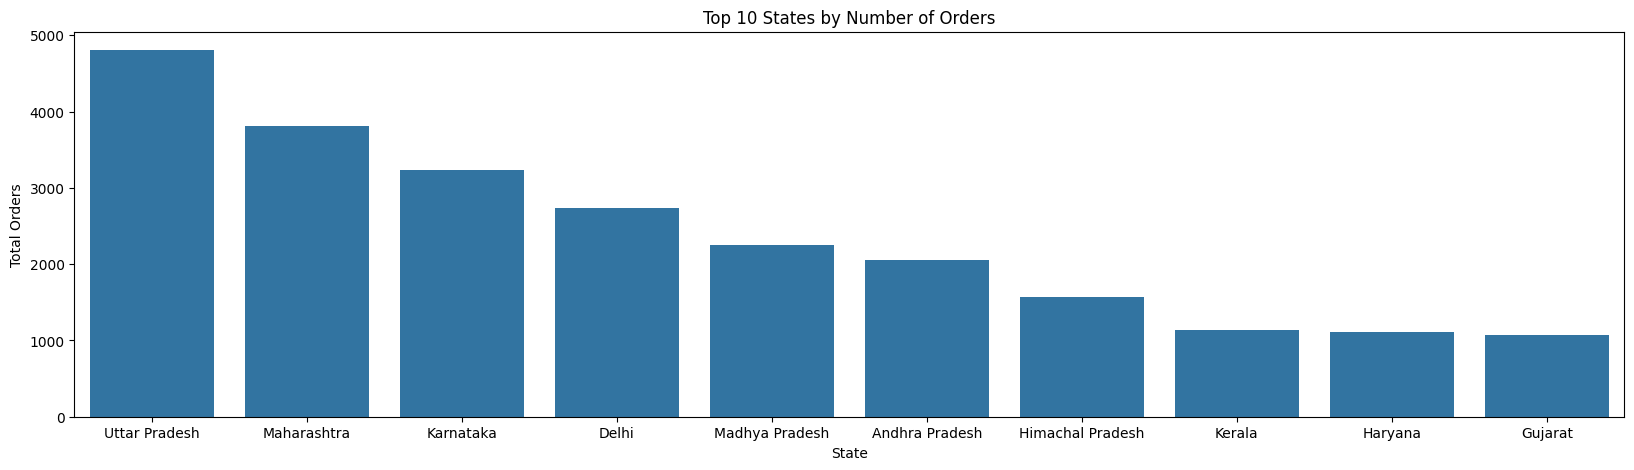

In [19]:
state_orders = df.groupby('State', as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
plt.figure(figsize=(20,5))
sns.barplot(x='State', y='Orders', data=state_orders)
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Total Orders')
plt.show()

**From the graph above, we can see that most orders and total sales come from Uttar Pradesh, Maharashtra, and Karnataka respectively.**

## Marital Status

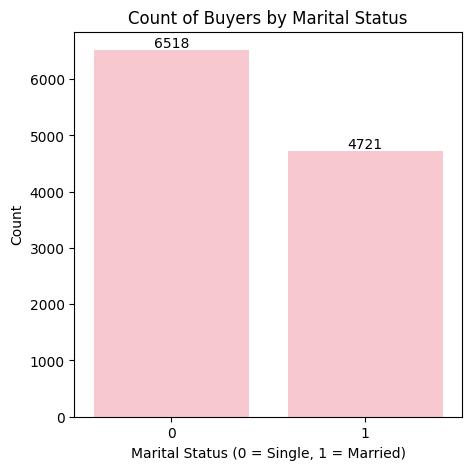

In [20]:
plt.figure(figsize=(5,5))
ax = sns.countplot(data=df, x='Marital_Status', color='pink')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Count of Buyers by Marital Status')
plt.xlabel('Marital Status (0 = Single, 1 = Married)')
plt.ylabel('Count')
plt.show()

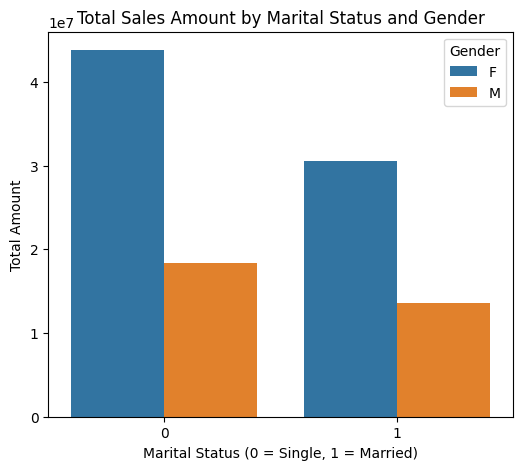

In [21]:
marital_gender_sales = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
plt.figure(figsize=(6,5))
sns.barplot(x='Marital_Status', y='Amount', hue='Gender', data=marital_gender_sales)
plt.title('Total Sales Amount by Marital Status and Gender')
plt.xlabel('Marital Status (0 = Single, 1 = Married)')
plt.ylabel('Total Amount')
plt.show()

**From the graphs above, we can see that most buyers are married women, and they have higher purchasing power.**

## Occupation

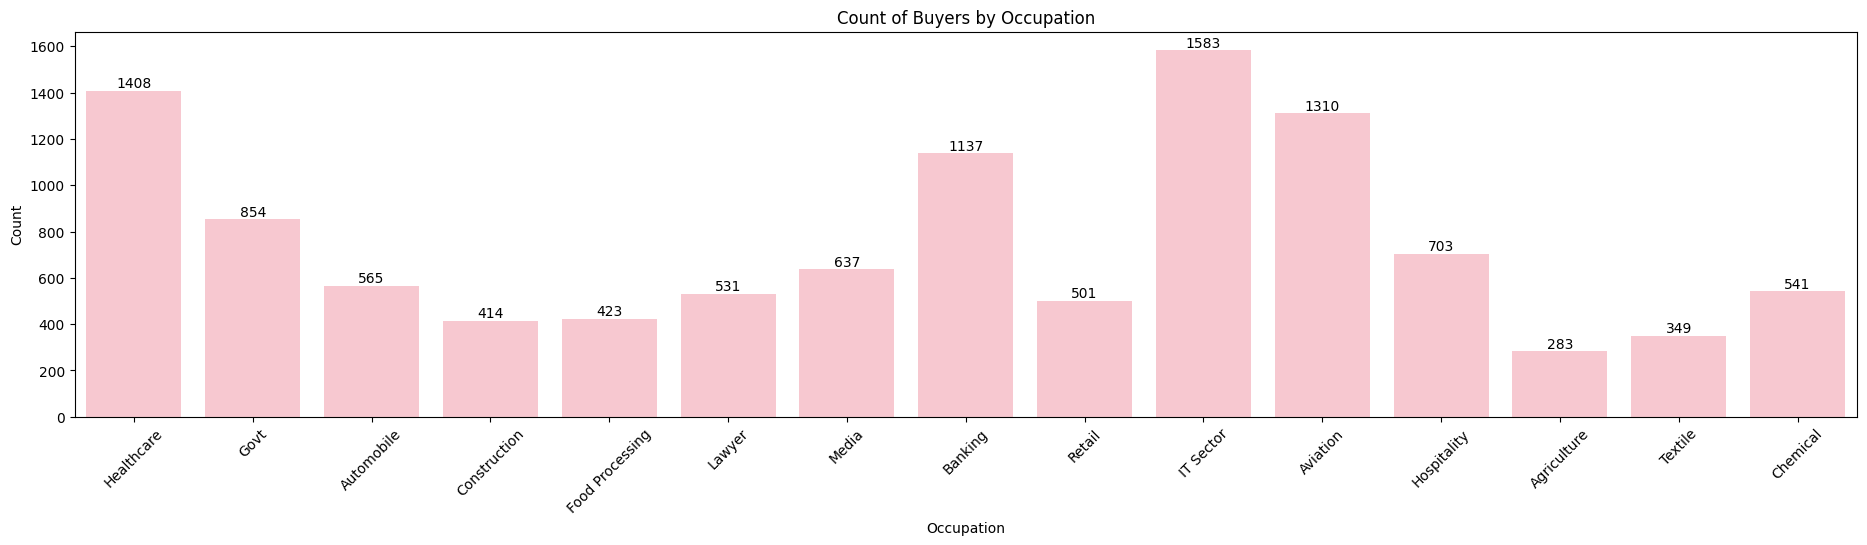

In [22]:
plt.figure(figsize=(23,5))
ax = sns.countplot(data=df, x='Occupation', color='pink')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Count of Buyers by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

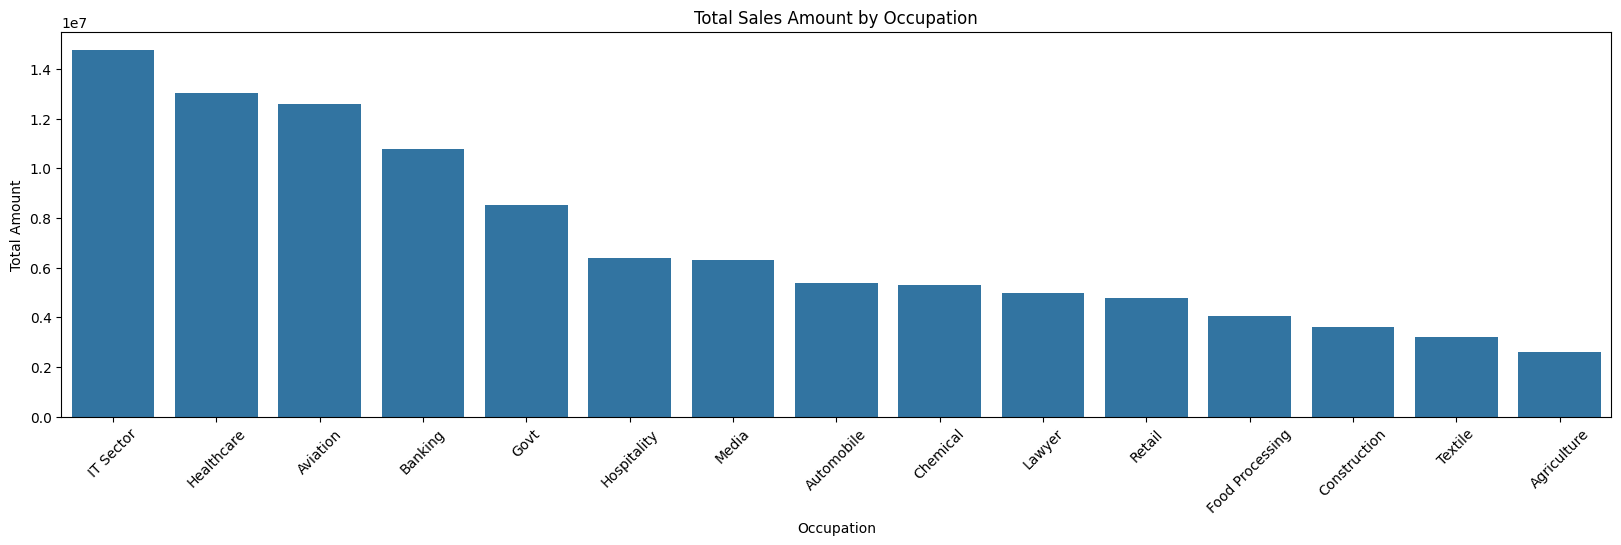

In [23]:
occupation_sales = df.groupby('Occupation', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
plt.figure(figsize=(20,5))
sns.barplot(x='Occupation', y='Amount', data=occupation_sales)
plt.title('Total Sales Amount by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

**From the graph above, we can see that most buyers work in the IT, Healthcare, and Aviation sectors.**

## Product Category

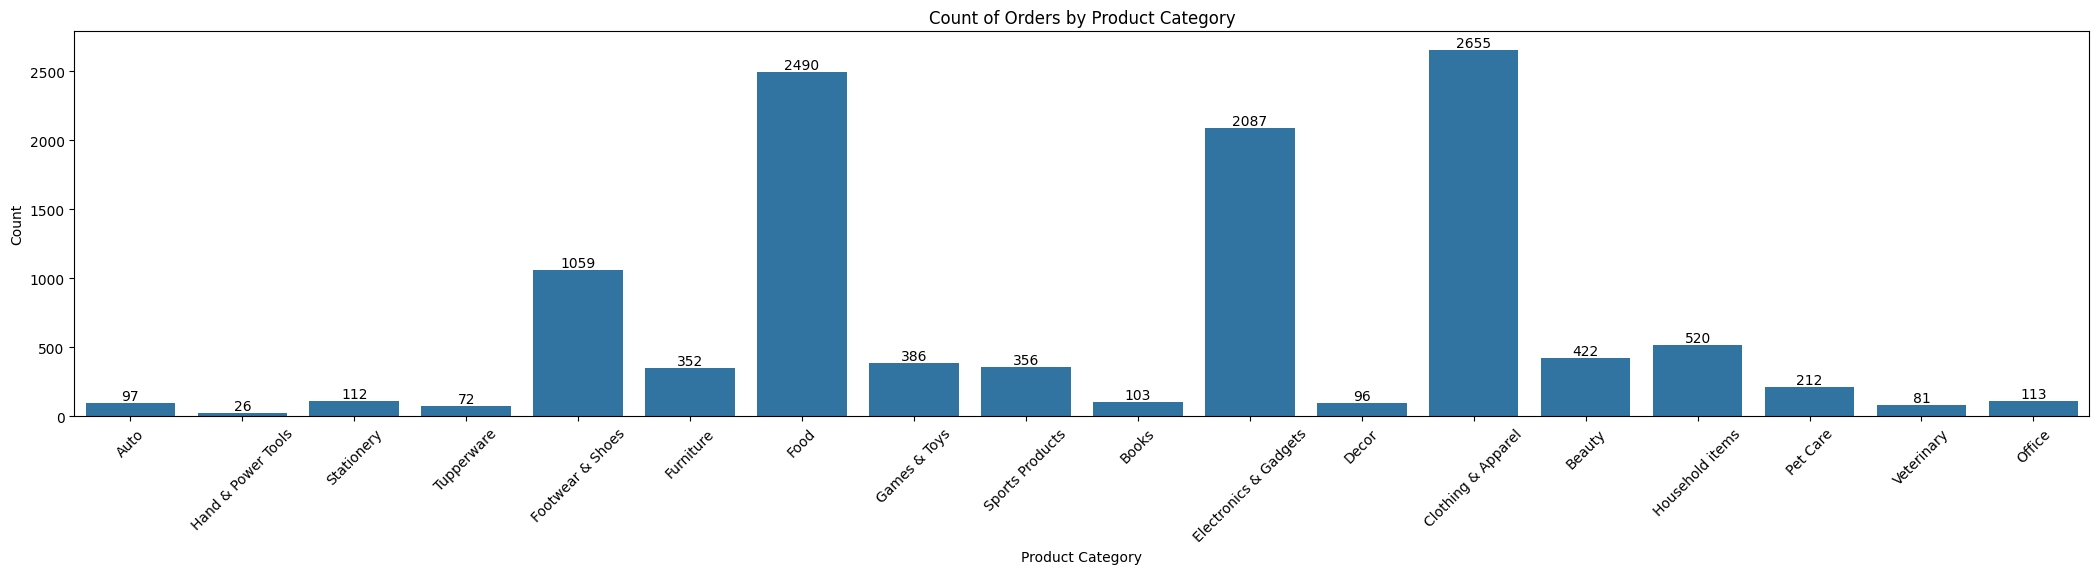

In [24]:
plt.figure(figsize=(26,5))
ax = sns.countplot(data=df, x='Product_Category')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Count of Orders by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

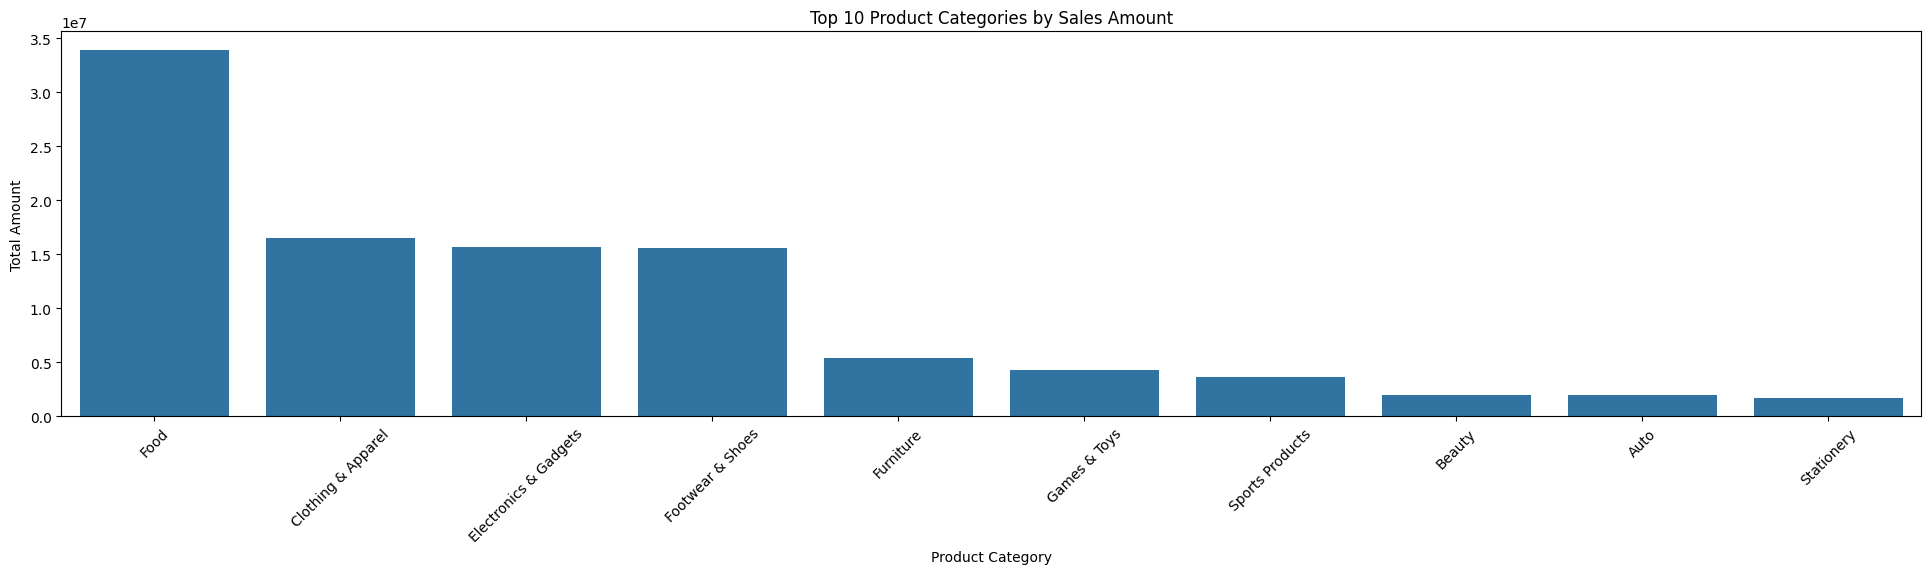

In [25]:
category_sales = df.groupby('Product_Category', as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
plt.figure(figsize=(24,5))
sns.barplot(x='Product_Category', y='Amount', data=category_sales)
plt.title('Top 10 Product Categories by Sales Amount')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

**From the graphs above, we can see that the most sold products are in the Clothing, Electronics, and Food categories.**

## Top 10 Most Sold Products

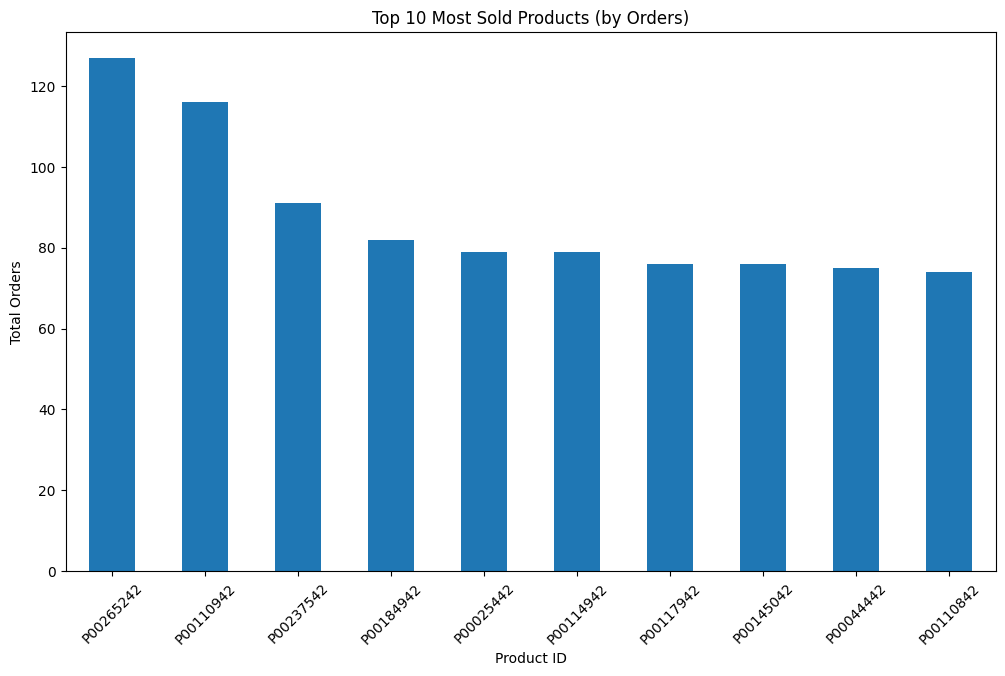

In [26]:
top_products = df.groupby('Product_ID')['Orders'].sum().nlargest(10)
plt.figure(figsize=(12,7))
top_products.plot(kind='bar')
plt.title('Top 10 Most Sold Products (by Orders)')
plt.xlabel('Product ID')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.show()

**These are the top 10 individual products by order volume — useful for inventory planning and targeted promotions in future campaigns.**

# Conclusion

**Married women aged 26–35 years from Uttar Pradesh, Maharashtra, and Karnataka, working in IT, Healthcare, and Aviation, are the most likely to purchase Food, Clothing, and Electronics products. Targeting this segment could help maximize sales in future campaigns.**